In [53]:
# imports
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [54]:
# Load the dataset

gym_data = pd.read_csv("gym_injury_data.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [55]:
# Check for duplicates and remove them
gym_data = gym_data.drop_duplicates()

In [56]:
# Create a copy of the dataset for encoding
gym_data_encoded = gym_data.copy()

In [57]:
# Encode categorical variables. 
gym_data_encoded["Warm_Up_Completed"] = gym_data_encoded["Warm_Up_Completed"].map({
    "Yes": 1,
    "No": 0
})

gym_data_encoded["Previous_Injury"] = gym_data_encoded["Previous_Injury"].map({
    "Yes": 1,
    "No": 0
})

gym_data_encoded["Intensity_Level"] = gym_data_encoded["Intensity_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

gym_data_encoded["Hydration_Level"] = gym_data_encoded["Hydration_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

gym_data_encoded["Injury_Risk"] = gym_data_encoded["Injury_Risk"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

gym_data_encoded = pd.get_dummies(
    gym_data_encoded,
    columns=["Gender", "Workout_Type"],
    drop_first=True
)

In [58]:
# Separate features and labels
features = gym_data_encoded.drop("Injury_Risk", axis=1)
labels = gym_data_encoded["Injury_Risk"]

In [59]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.20,
    random_state=3,
    stratify=labels
)

In [60]:
# Define the models to be evaluated

models = {
    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier(max_depth=5, random_state=3))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=100, random_state=3))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1, max_iter=1000))
    ])
}

In [61]:
# Train and evaluate each model
model_scores = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    model_scores[model_name] = accuracy

print("\nModel Accuracy Scores:")
print(model_scores)


Model Accuracy Scores:
{'Decision Tree': 0.7083333333333334, 'Random Forest': 0.85, 'KNN': 0.5666666666666667, 'Logistic Regression': 0.8166666666666667}


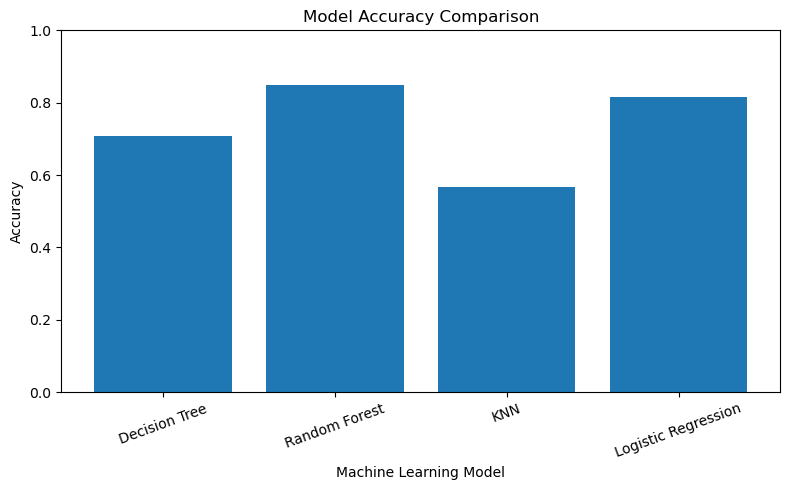

In [62]:
# Visualize the model performance
plt.figure(figsize=(8, 5))
plt.bar(model_scores.keys(), model_scores.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [63]:
# Identify the best model based on accuracy
best_model_name = max(model_scores, key=model_scores.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Accuracy:", model_scores[best_model_name])


Best Model: Random Forest
Best Accuracy: 0.85


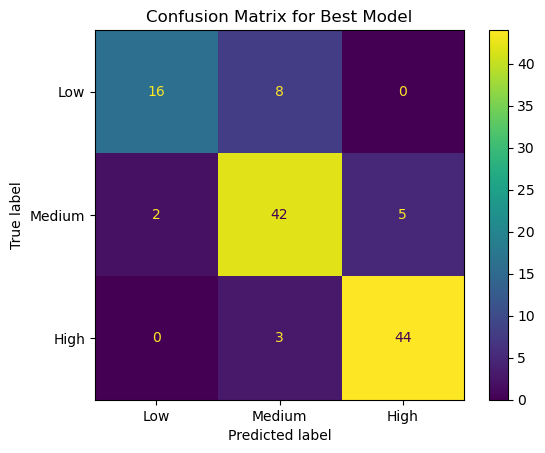

In [64]:
# Generate predictions from the best model
best_predictions = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    display_labels=["Low", "Medium", "High"]
)

plt.title("Confusion Matrix for Best Model")
plt.show()

In [65]:
# Save the best model
joblib.dump(best_model, "best_gym_injury_model.pkl")

print("\nBest model saved successfully.")


Best model saved successfully.


In [66]:
print("\nEnter new user workout information:")

new_user = {
    "Age": int(input("Age: ")),
    "Workouts_Per_Week": int(input("Workouts per week: ")),
    "Workout_Duration": int(input("Workout duration in minutes: ")),
    "Intensity_Level": input("Intensity level: Low, Medium, or High: "),
    "Sleep_Hours": float(input("Sleep hours: ")),
    "Recovery_Days": int(input("Recovery days per week: ")),
    "Warm_Up_Completed": input("Warm-up completed? Yes or No: "),
    "Previous_Injury": input("Previous injury? Yes or No: "),
    "Pain_Level_After_Workout": int(input("Pain level after workout 0-10: ")),
    "Hydration_Level": input("Hydration level: Low, Medium, or High: "),
    "Gender_Male": 1 if input("Gender: Female or Male: ") == "Male" else 0,
    "Workout_Type_HIIT": 0,
    "Workout_Type_Mixed": 0,
    "Workout_Type_Strength Training": 0,
    "Workout_Type_Yoga": 0
}

workout_type = input("Workout type: Cardio, HIIT, Mixed, Strength Training, or Yoga: ")

if workout_type == "HIIT":
    new_user["Workout_Type_HIIT"] = 1
elif workout_type == "Mixed":
    new_user["Workout_Type_Mixed"] = 1
elif workout_type == "Strength Training":
    new_user["Workout_Type_Strength Training"] = 1
elif workout_type == "Yoga":
    new_user["Workout_Type_Yoga"] = 1



Enter new user workout information:


I entered in the following information:
Age: 18
Workouts Per Week: 2
Workout Duration in Minutes: 60
Intensity Level: High
Sleep Hours: 6
Recovery Days Per Week: 4
Warm Up Completed: No
Previous Injury: Yes
Pain Level After Workout: 4
Hydration Level: Medium
Gender: Female
Workout Type: Strength Training


In [67]:
# Encode the new user data
new_user["Warm_Up_Completed"] = 1 if new_user["Warm_Up_Completed"] == "Yes" else 0
new_user["Previous_Injury"] = 1 if new_user["Previous_Injury"] == "Yes" else 0

new_user["Intensity_Level"] = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}[new_user["Intensity_Level"]]

new_user["Hydration_Level"] = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}[new_user["Hydration_Level"]]


In [68]:
# Create a DataFrame for the new user data
new_user_data = pd.DataFrame([new_user])

new_user_data = new_user_data.reindex(columns=features.columns, fill_value=0)

prediction = best_model.predict(new_user_data)[0]

risk_labels = {
    0: "Low",
    1: "Medium",
    2: "High"
}

print("\nPredicted Injury Risk:", risk_labels[prediction])


Predicted Injury Risk: High
